In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

data_folder = "data/analyser_comparisons"

dfs = {}
for file in glob.glob(os.path.join(data_folder, "*")):
    with open(file) as f:
        lines = f.readlines()

    # remove comment/header line starting with "#"
    data_lines = [l for l in lines if not l.startswith("#")]

    # read the remaining data as CSV
    from io import StringIO
    df = pd.read_csv(StringIO("".join(data_lines)))
    dfs[os.path.basename(file)] = df

for name, df in dfs.items():
    df["o2_residual"] = df["o2"] - df["control_o2"]
    df["he_residual"] = df["he"] - df["control_he"]

def jitter(x, amt=0.2):
    return x + np.random.normal(0, amt, size=len(x))

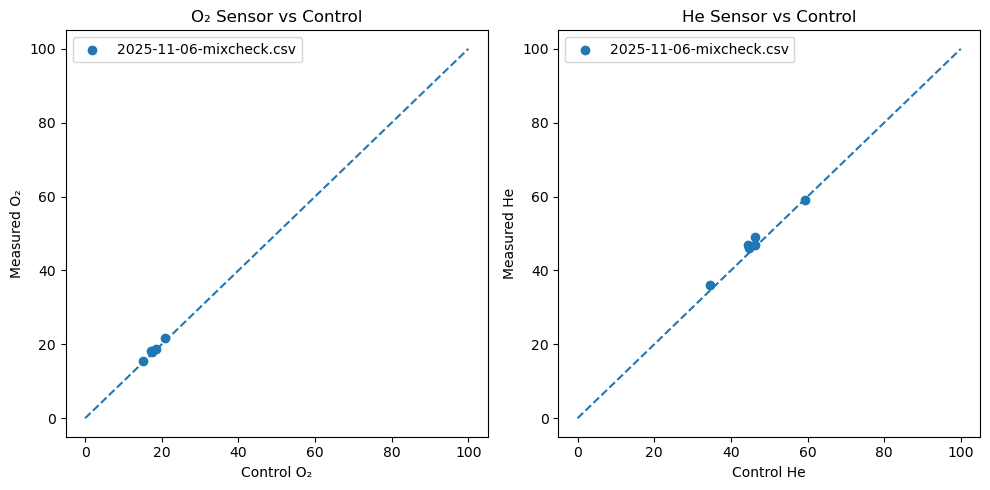

In [2]:
# ------------ Basic plots ------------
plt.figure(figsize=(10,5))

# --- O2 ---
plt.subplot(1,2,1)
for name, df in dfs.items():
    plt.scatter(df["control_o2"], df["o2"], label=name)
plt.plot([0,100],[0,100], linestyle="--")  # ideal accuracy line
plt.title("O₂ Sensor vs Control")
plt.xlabel("Control O₂")
plt.ylabel("Measured O₂")
plt.legend()

# --- He ---
plt.subplot(1,2,2)
for name, df in dfs.items():
    plt.scatter(df["control_he"], df["he"], label=name)
plt.plot([0,100],[0,100], linestyle="--")  # ideal accuracy line
plt.title("He Sensor vs Control")
plt.xlabel("Control He")
plt.ylabel("Measured He")
plt.legend()

plt.tight_layout()

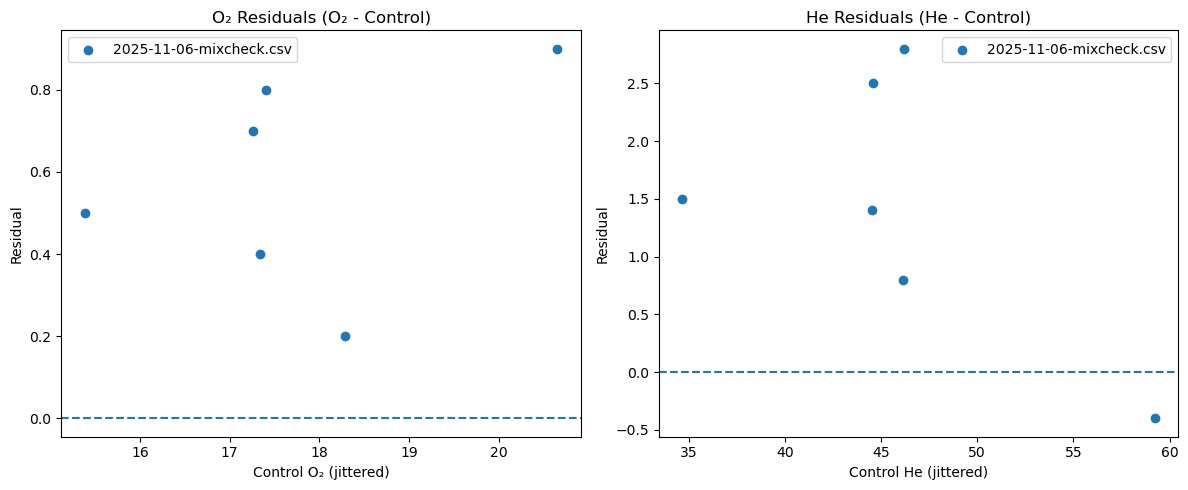

In [3]:
# ------------ Plot residual scatter ------------
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
for name, df in dfs.items():
    plt.scatter(jitter(df["control_o2"]), df["o2_residual"], label=name)
plt.axhline(0, linestyle="--")
plt.title("O₂ Residuals (O₂ - Control)")
plt.xlabel("Control O₂ (jittered)")
plt.ylabel("Residual")
plt.legend()

plt.subplot(1,2,2)
for name, df in dfs.items():
    plt.scatter(jitter(df["control_he"]), df["he_residual"], label=name)
plt.axhline(0, linestyle="--")
plt.title("He Residuals (He - Control)")
plt.xlabel("Control He (jittered)")
plt.ylabel("Residual")
plt.legend()

plt.tight_layout()

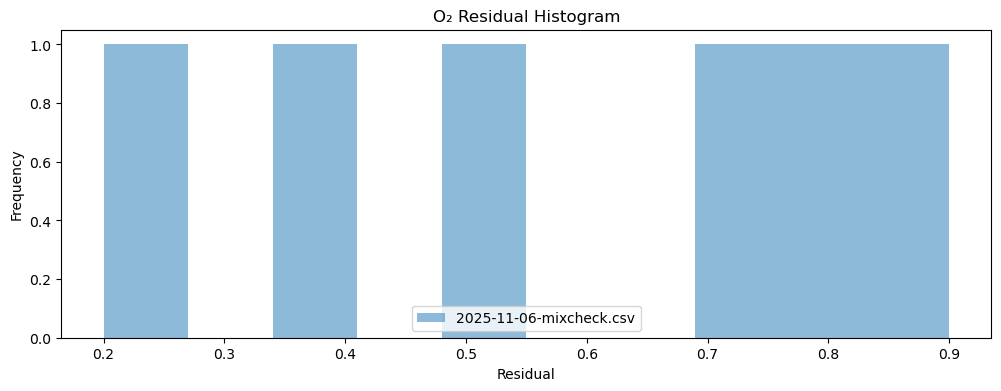

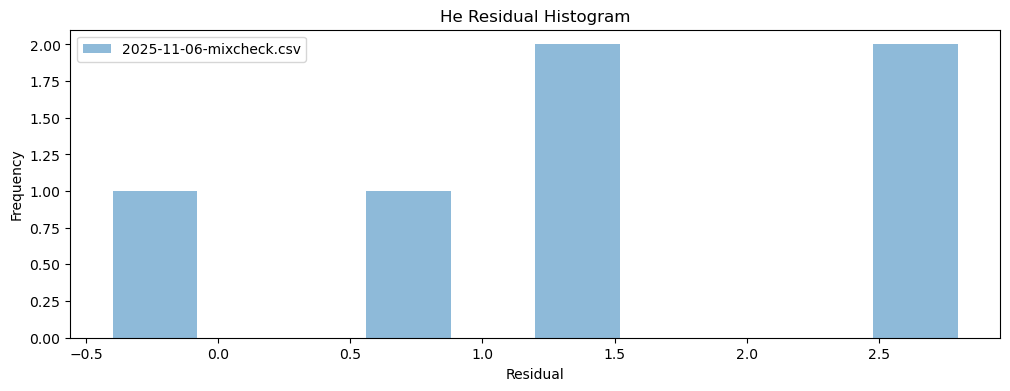

In [4]:
# ------------ Histograms ------------
plt.figure(figsize=(12,4))
for name, df in dfs.items():
    plt.hist(df["o2_residual"], alpha=0.5, label=name)
plt.title("O₂ Residual Histogram")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.legend()

plt.figure(figsize=(12,4))
for name, df in dfs.items():
    plt.hist(df["he_residual"], alpha=0.5, label=name)
plt.title("He Residual Histogram")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.legend()

Text(0.5, 0, 'Residual')

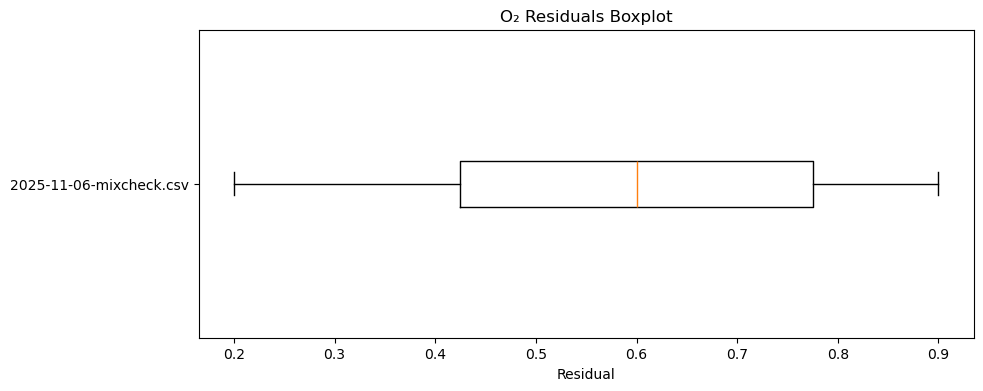

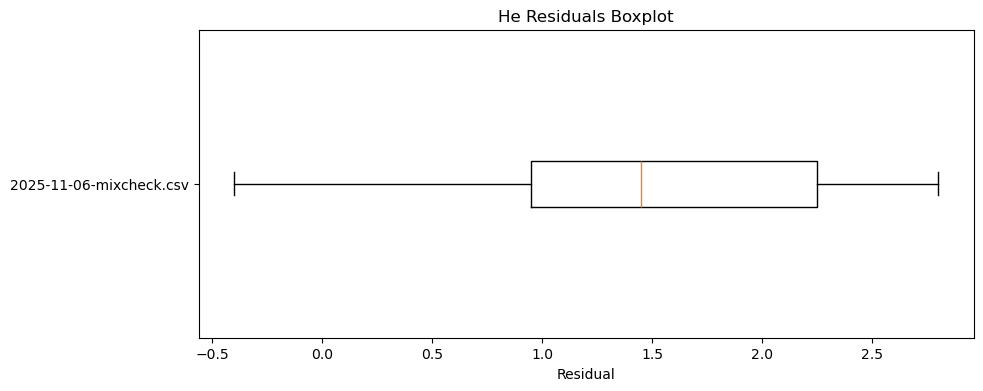

In [5]:
# ------------ Boxplots ------------
plt.figure(figsize=(10,4))
plt.boxplot([df["o2_residual"] for df in dfs.values()],
            tick_labels=list(dfs.keys()), vert=False)
plt.title("O₂ Residuals Boxplot")
plt.xlabel("Residual")

plt.figure(figsize=(10,4))
plt.boxplot([df["he_residual"] for df in dfs.values()],
            tick_labels=list(dfs.keys()), vert=False)
plt.title("He Residuals Boxplot")
plt.xlabel("Residual")